EMPLOYEE ATTRITION PREDICTION

Dataset not found locally.
Dataset downloaded successfully.
Dataset extracted successfully.

Dataset loaded successfully!
Dataset Shape: (1470, 35)

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2



DATA PREPARATION
Shape after preprocessing: (1470, 31)

ATTRITION DISTRIBUTION
Attrition
0    1233
1     237
Name: count, dtype: int64

Attrition Percentage:
Attrition
0    83.877551
1    16.122449
Name: proportion, dtype: float64

TEXT ANALYTICS

Sample Text Data:


,Attrition,Exit_Interview_Note,Sentiment_Score
0,1,I am leaving because of better offer.,0.5
1,0,I like the supportive culture.,0.5
2,1,I am leaving because of bad manager.,-0.7
3,0,I like the work life balance.,0.0
4,0,I like the work life balance.,0.0



FEATURE ENGINEERING
Number of model features: 44

Training records: 1029
Testing records: 441

LOGISTIC REGRESSION

Accuracy: 0.8798
ROC-AUC: 0.8204

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       370
           1       0.72      0.41      0.52        71

    accuracy                           0.88       441
   macro avg       0.81      0.69      0.73       441
weighted avg       0.87      0.88      0.87       441


DECISION TREE

Accuracy: 0.8390
ROC-AUC: 0.7140

MODEL COMPARISON


,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.879819,0.820404
1,Decision Tree,0.839002,0.714046


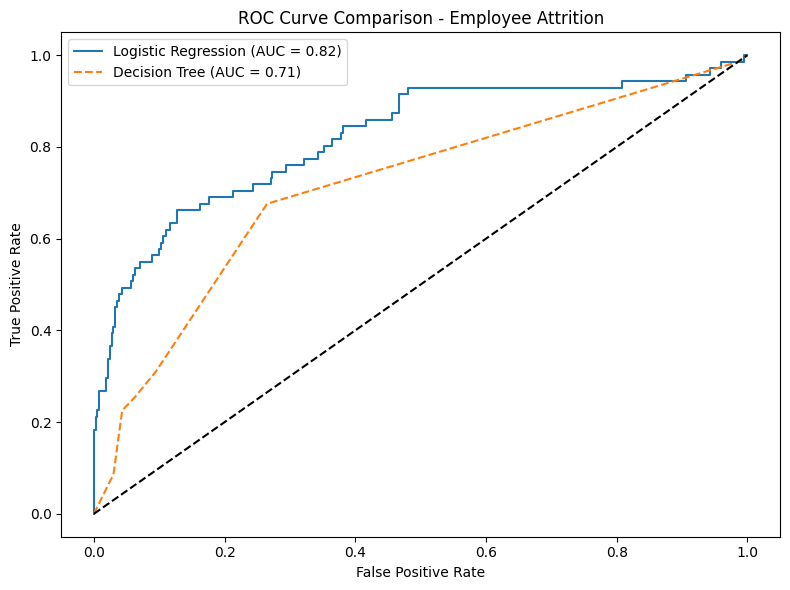

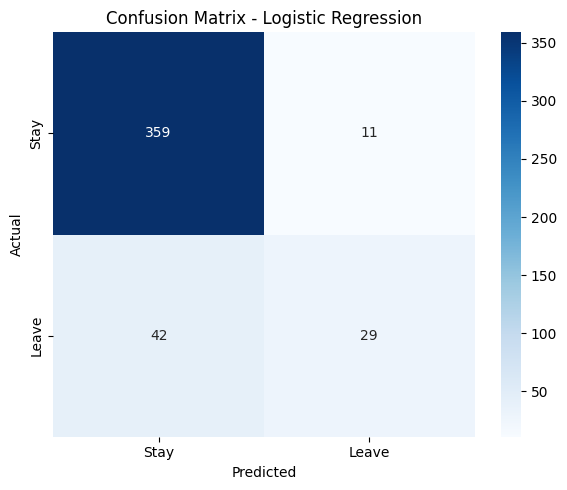

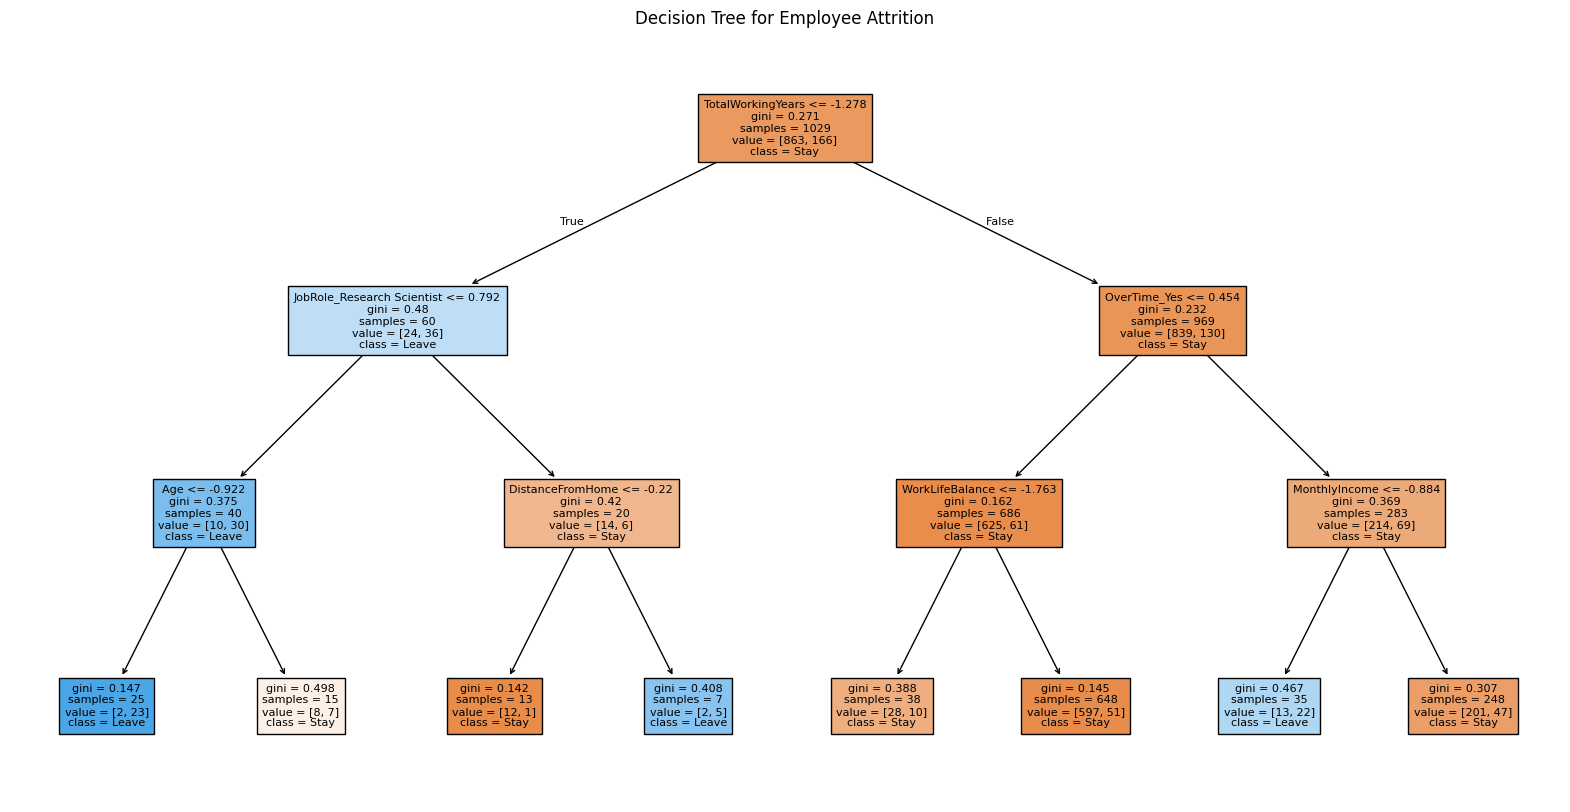


K-MEANS EMPLOYEE SEGMENTATION

Cluster Summary:


,MonthlyIncome,TotalWorkingYears,Attrition
Cluster,,,
0,3260.159940,5.448430,0.228700
1,15584.402655,25.438053,0.075221
2,6706.412174,12.499130,0.116522


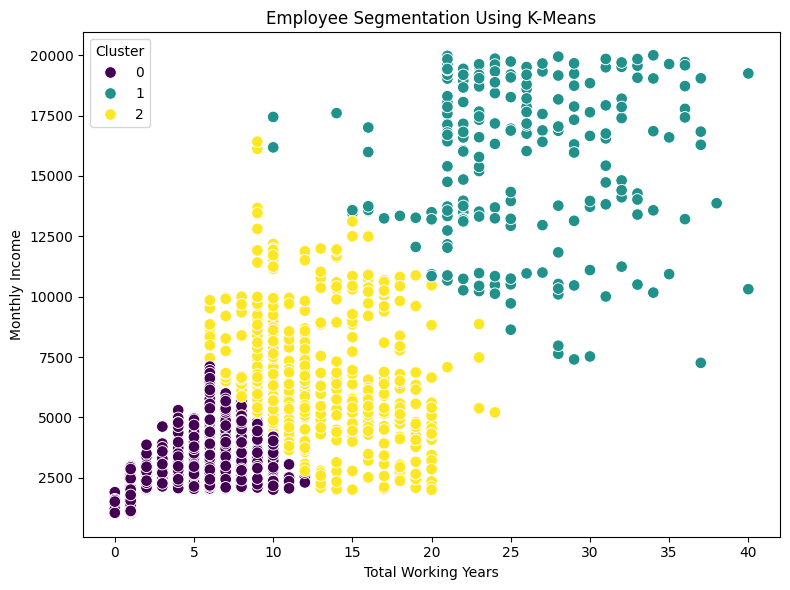

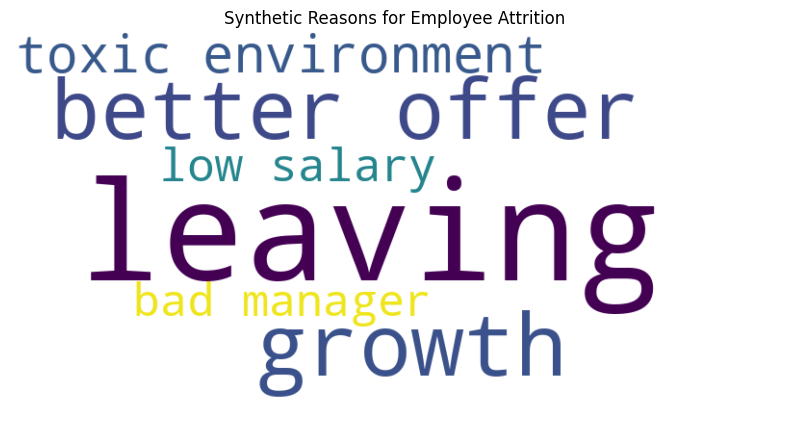


TOP ATTRITION DRIVERS

Top Positive Drivers:


,Feature,Coefficient
43,OverTime_Yes,0.868609
23,BusinessTravel_Travel_Frequently,0.689218
34,JobRole_Laboratory Technician,0.670609
21,YearsSinceLastPromotion,0.616252
39,JobRole_Sales Executive,0.613567
40,JobRole_Sales Representative,0.558015
11,NumCompaniesWorked,0.491335
42,MaritalStatus_Single,0.401519
24,BusinessTravel_Travel_Rarely,0.395709
2,DistanceFromHome,0.356526



Top Negative Drivers:


,Feature,Coefficient
30,EducationField_Other,-0.339968
6,JobInvolvement,-0.347294
14,RelationshipSatisfaction,-0.372609
27,EducationField_Life Sciences,-0.389313
29,EducationField_Medical,-0.397371
0,Age,-0.421568
8,JobSatisfaction,-0.430645
20,YearsInCurrentRole,-0.439430
4,EnvironmentSatisfaction,-0.450709
16,TotalWorkingYears,-0.459928


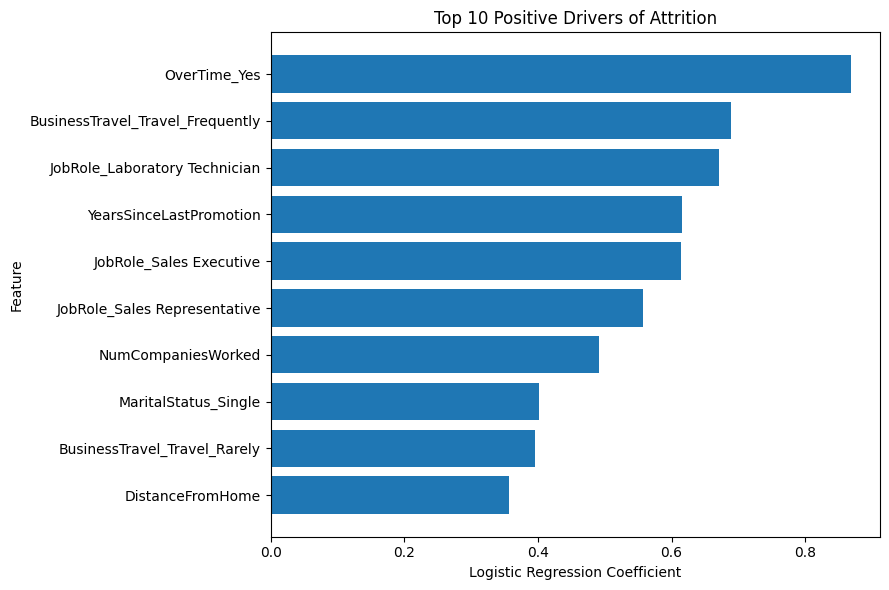


EMPLOYEE ATTRITION RISK SCORING

Sample Risk Scores:


,Actual_Attrition,Attrition_Probability,High_Risk
397,0,0.498630,True
832,0,0.027786,False
483,0,0.295629,False
456,0,0.070767,False
1342,0,0.039476,False
104,0,0.001694,False
846,0,0.018459,False
178,0,0.014891,False
207,0,0.344167,False
231,0,0.002722,False


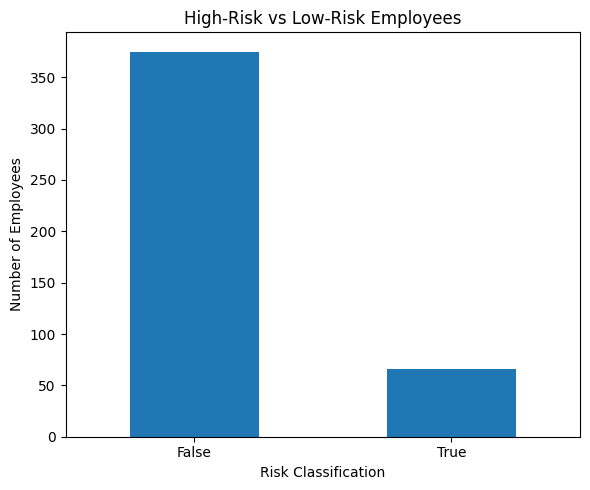



                 FINAL RESULTS

Dataset Size: 1470 employees
Number of Features: 44

Logistic Regression Accuracy: 87.98%
Logistic Regression ROC-AUC: 0.82

Decision Tree Accuracy: 83.90%
Decision Tree ROC-AUC: 0.71

Number of Employee Clusters: 3
High-Risk Employees Identified: 66

              ANALYSIS COMPLETE


In [1]:
# ============================================================
# EMPLOYEE ATTRITION PREDICTION USING MACHINE LEARNING
# WAI - IIM Ranchi
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import random
import zipfile
import requests

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

from textblob import TextBlob
from wordcloud import WordCloud


# ============================================================
# 2. AUTOMATICALLY DOWNLOAD DATASET
# ============================================================

print("=" * 60)
print("EMPLOYEE ATTRITION PREDICTION")
print("=" * 60)

csv_file = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

if not os.path.exists(csv_file):

    print("\nDataset not found locally.")
    print("Downloading IBM HR Analytics dataset...")

    url = (
        "https://www.kaggle.com/api/v1/datasets/download/"
        "pavansubhasht/ibm-hr-analytics-attrition-dataset"
    )

    zip_file = "ibm-hr-analytics.zip"

    response = requests.get(url)

    if response.status_code != 200:
        raise Exception(
            "Dataset download failed. "
            f"HTTP status: {response.status_code}"
        )

    with open(zip_file, "wb") as f:
        f.write(response.content)

    print("Dataset downloaded successfully.")

    # Extract ZIP
    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall(".")

    print("Dataset extracted successfully.")

else:

    print("\nDataset already available.")


# ============================================================
# 3. LOAD DATA
# ============================================================

df = pd.read_csv(csv_file)

print("\nDataset loaded successfully!")
print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())


# ============================================================
# 4. DATA PREPARATION
# ============================================================

print("\n" + "=" * 60)
print("DATA PREPARATION")
print("=" * 60)

# Convert target variable
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

# Remove non-informative variables
drop_cols = [
    "EmployeeNumber",
    "EmployeeCount",
    "Over18",
    "StandardHours"
]

df = df.drop(
    columns=drop_cols,
    errors="ignore"
)

print("Shape after preprocessing:", df.shape)


# ============================================================
# 5. ATTRITION DISTRIBUTION
# ============================================================

print("\n" + "=" * 60)
print("ATTRITION DISTRIBUTION")
print("=" * 60)

attrition_count = df["Attrition"].value_counts()

print(attrition_count)

attrition_percentage = (
    df["Attrition"].value_counts(normalize=True) * 100
)

print("\nAttrition Percentage:")
print(attrition_percentage)


# ============================================================
# 6. SYNTHETIC TEXT ANALYTICS
# ============================================================
#
# IMPORTANT:
# The IBM HR dataset does not contain actual exit-interview text.
# Therefore, synthetic text is generated only to demonstrate
# TextBlob sentiment analysis.
#
# Sentiment_Score is NOT used as a model feature because the
# synthetic text is generated from Attrition and would otherwise
# cause target leakage.
# ============================================================

print("\n" + "=" * 60)
print("TEXT ANALYTICS")
print("=" * 60)


def generate_feedback(row):

    if row["Attrition"] == 1:

        reasons = [
            "toxic environment",
            "low salary",
            "bad manager",
            "no growth",
            "better offer"
        ]

        return (
            "I am leaving because of "
            + random.choice(reasons)
            + "."
        )

    else:

        reasons = [
            "great team",
            "good benefits",
            "learning a lot",
            "supportive culture",
            "work life balance"
        ]

        return (
            "I like the "
            + random.choice(reasons)
            + "."
        )


df["Exit_Interview_Note"] = df.apply(
    generate_feedback,
    axis=1
)


# Sentiment analysis
df["Sentiment_Score"] = df[
    "Exit_Interview_Note"
].apply(
    lambda x: TextBlob(x).sentiment.polarity
)


print("\nSample Text Data:")

display(
    df[
        [
            "Attrition",
            "Exit_Interview_Note",
            "Sentiment_Score"
        ]
    ].head()
)


# ============================================================
# 7. CATEGORICAL ENCODING
# ============================================================

print("\n" + "=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

cat_cols = df.select_dtypes(
    include="object"
).columns


# Do not encode synthetic text
if "Exit_Interview_Note" in cat_cols:

    cat_cols = cat_cols.drop(
        "Exit_Interview_Note"
    )


df_encoded = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True
)


# ============================================================
# 8. FEATURES AND TARGET
# ============================================================

# IMPORTANT:
# Sentiment_Score is deliberately excluded because it is
# derived from synthetic text generated using Attrition.

X = df_encoded.drop(
    [
        "Attrition",
        "Exit_Interview_Note",
        "Sentiment_Score"
    ],
    axis=1
)

y = df_encoded["Attrition"]

print("Number of model features:", X.shape[1])


# ============================================================
# 9. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\nTraining records:", len(X_train))
print("Testing records:", len(X_test))


# ============================================================
# 10. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)


# ============================================================
# 11. LOGISTIC REGRESSION
# ============================================================

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)

log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train_scaled,
    y_train
)


# Predictions
y_pred_log = log_model.predict(
    X_test_scaled
)

y_prob_log = log_model.predict_proba(
    X_test_scaled
)[:, 1]


# Metrics
log_accuracy = accuracy_score(
    y_test,
    y_pred_log
)

log_auc = roc_auc_score(
    y_test,
    y_prob_log
)


print(
    f"\nAccuracy: {log_accuracy:.4f}"
)

print(
    f"ROC-AUC: {log_auc:.4f}"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_log
    )
)


# ============================================================
# 12. DECISION TREE
# ============================================================

print("\n" + "=" * 60)
print("DECISION TREE")
print("=" * 60)

tree_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_model.fit(
    X_train_scaled,
    y_train
)


y_pred_tree = tree_model.predict(
    X_test_scaled
)

y_prob_tree = tree_model.predict_proba(
    X_test_scaled
)[:, 1]


tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

tree_auc = roc_auc_score(
    y_test,
    y_prob_tree
)


print(
    f"\nAccuracy: {tree_accuracy:.4f}"
)

print(
    f"ROC-AUC: {tree_auc:.4f}"
)


# ============================================================
# 13. MODEL COMPARISON
# ============================================================

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],

    "Accuracy": [
        log_accuracy,
        tree_accuracy
    ],

    "ROC-AUC": [
        log_auc,
        tree_auc
    ]

})

display(comparison)


# ============================================================
# 14. ROC CURVE
# ============================================================

fpr_log, tpr_log, _ = roc_curve(
    y_test,
    y_prob_log
)

fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    y_prob_tree
)


plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {log_auc:.2f})"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    linestyle="--",
    label=f"Decision Tree (AUC = {tree_auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "k--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison - Employee Attrition"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 15. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred_log
)


plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stay", "Leave"],
    yticklabels=["Stay", "Leave"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix - Logistic Regression"
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. DECISION TREE VISUALIZATION
# ============================================================

plt.figure(
    figsize=(20, 10)
)

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Stay", "Leave"],
    filled=True,
    fontsize=8
)

plt.title(
    "Decision Tree for Employee Attrition"
)

plt.show()


# ============================================================
# 17. K-MEANS CLUSTERING
# ============================================================

print("\n" + "=" * 60)
print("K-MEANS EMPLOYEE SEGMENTATION")
print("=" * 60)

cluster_cols = [
    "MonthlyIncome",
    "TotalWorkingYears"
]


cluster_data = df[
    cluster_cols
].copy()


cluster_scaler = StandardScaler()

cluster_scaled = cluster_scaler.fit_transform(
    cluster_data
)


kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(
    cluster_scaled
)


cluster_summary = df.groupby(
    "Cluster"
)[
    [
        "MonthlyIncome",
        "TotalWorkingYears",
        "Attrition"
    ]
].mean()


print("\nCluster Summary:")

display(cluster_summary)


# ============================================================
# 18. K-MEANS VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="TotalWorkingYears",
    y="MonthlyIncome",
    hue="Cluster",
    palette="viridis",
    s=70
)

plt.title(
    "Employee Segmentation Using K-Means"
)

plt.xlabel(
    "Total Working Years"
)

plt.ylabel(
    "Monthly Income"
)

plt.tight_layout()

plt.show()


# ============================================================
# 19. TEXT ANALYTICS - WORD CLOUD
# ============================================================

leavers_text = " ".join(
    df[
        df["Attrition"] == 1
    ]["Exit_Interview_Note"]
)


wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(
    leavers_text
)


plt.figure(
    figsize=(10, 5)
)

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Synthetic Reasons for Employee Attrition"
)

plt.show()


# ============================================================
# 20. FEATURE IMPORTANCE
# ============================================================

coef_df = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": log_model.coef_[0]

})


coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)


print("\n" + "=" * 60)
print("TOP ATTRITION DRIVERS")
print("=" * 60)

print("\nTop Positive Drivers:")

display(
    coef_df.head(10)
)


print("\nTop Negative Drivers:")

display(
    coef_df.tail(10)
)


# ============================================================
# 21. TOP DRIVERS VISUALIZATION
# ============================================================

top10 = coef_df.head(10)


plt.figure(
    figsize=(9, 6)
)

plt.barh(
    top10["Feature"],
    top10["Coefficient"]
)

plt.gca().invert_yaxis()

plt.xlabel(
    "Logistic Regression Coefficient"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top 10 Positive Drivers of Attrition"
)

plt.tight_layout()

plt.show()


# ============================================================
# 22. EMPLOYEE ATTRITION RISK SCORING
# ============================================================

print("\n" + "=" * 60)
print("EMPLOYEE ATTRITION RISK SCORING")
print("=" * 60)


results = X_test.copy()

results["Actual_Attrition"] = (
    y_test.values
)

results["Attrition_Probability"] = (
    y_prob_log
)


# Risk threshold
threshold = 0.35

results["High_Risk"] = (
    results["Attrition_Probability"]
    > threshold
)


print("\nSample Risk Scores:")

display(
    results[
        [
            "Actual_Attrition",
            "Attrition_Probability",
            "High_Risk"
        ]
    ].head(10)
)


# ============================================================
# 23. HIGH-RISK VS LOW-RISK
# ============================================================

risk_counts = (
    results["High_Risk"]
    .value_counts()
)


plt.figure(
    figsize=(6, 5)
)

risk_counts.plot(
    kind="bar"
)

plt.title(
    "High-Risk vs Low-Risk Employees"
)

plt.xlabel(
    "Risk Classification"
)

plt.ylabel(
    "Number of Employees"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.show()


# ============================================================
# 24. FINAL RESULTS
# ============================================================

print("\n")
print("=" * 60)
print("                 FINAL RESULTS")
print("=" * 60)

print(
    f"\nDataset Size: {len(df)} employees"
)

print(
    f"Number of Features: {X.shape[1]}"
)

print(
    f"\nLogistic Regression Accuracy: "
    f"{log_accuracy:.2%}"
)

print(
    f"Logistic Regression ROC-AUC: "
    f"{log_auc:.2f}"
)

print(
    f"\nDecision Tree Accuracy: "
    f"{tree_accuracy:.2%}"
)

print(
    f"Decision Tree ROC-AUC: "
    f"{tree_auc:.2f}"
)

print(
    f"\nNumber of Employee Clusters: 3"
)

print(
    f"High-Risk Employees Identified: "
    f"{risk_counts.get(True, 0)}"
)

print("\n" + "=" * 60)
print("              ANALYSIS COMPLETE")
print("=" * 60)